<div style="display:block;width:100%;margin:auto;" direction=rtl align=center>
    <br><br>
    <div style="width:100%;margin:100;display:block;background-color:#fff0;" display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> Neural networks and deep learning</b><br><br>Computer Assignment 6</font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
            </tr>
        </table>
        <h1> Instructor: Dr. Ahmad Kalhor   </h1>
    </div>
</div>




<div dir="rtl">

#  نصب کتابخانه torchmetrics

In [1]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.5/963.5 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 105.4 MB/s eta 0:00:00


<div dir="rtl">

#  import کتابخانه های مورد نیاز

In [2]:
import os, shutil, zipfile
from collections import defaultdict
from typing import Any, Callable, Dict, List, Optional, Tuple
################################################################

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
################################################################

from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
from torchmetrics import Accuracy, MeanMetric
################################################################

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pickle
################################################################

from tqdm import tqdm


<div dir="rtl">

#  تعیین نوع device

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

<div dir="rtl">

# انتقال و extract داده ها به Colab

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
main_path = r'/content'
# Path to the zip file in Google Drive
source_path = os.path.join('/content/drive/MyDrive', 'dataset.zip')

# Destination path in Colab's temporary storage
destination_path = os.path.join(main_path, 'dataset.zip')

# Copy the file from Drive to Colab
shutil.copy(source_path, destination_path)

# Verify the file was copied
if os.path.exists(destination_path):
    print("File successfully copied!")
    print(f"File location: {destination_path}")
else:
    print("Error copying file!")


File successfully copied!
File location: /content/dataset.zip


In [6]:
# Define paths (using raw strings for Windows paths)
zip_path = os.path.join(main_path, 'dataset.zip')
extract_to = main_path

# Create directory if it doesn't exist
os.makedirs(extract_to, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

<div dir="rtl">

# تعریف Dataset دادگان test, train و همه دادگان برای دادگان mnist و mnistm

In [7]:
# 1. Load data from pkl files
with open('/content/mnist.pkl', 'rb') as f:
    mnist_data = pickle.load(f)

with open('/content/mnistm.pkl', 'rb') as f:
    mnistm_data = pickle.load(f)

# 2. Define custom Dataset class
class MNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# 3. Define transforms
transform_mnist = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_mnistm = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 4. Create Dataset objects
mnist_dataset = MNISTDataset(mnist_data[b'images'], mnist_data[b'labels'], transform=transform_mnist)
mnistm_dataset = MNISTDataset(mnistm_data[b'images'], mnistm_data[b'labels'], transform=transform_mnistm)

# 5. Stratified split for train/test, preserving label distribution and correspondence
labels = mnist_data[b'labels']
indices = np.arange(len(labels))
train_indices, test_indices = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=labels
)

mnist_train = Subset(mnist_dataset, train_indices)
mnist_test = Subset(mnist_dataset, test_indices)
mnistm_train = Subset(mnistm_dataset, train_indices)
mnistm_test = Subset(mnistm_dataset, test_indices)


<div dir="rtl">

# تعریف DataLoader دادگان test, train و همه دادگان برای دادگان mnist و mnistm

In [8]:
batch_size = 32

mnist_train_loader = DataLoader(mnist_train, batch_size=batch_size, num_workers=8, prefetch_factor=8, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=batch_size, num_workers=8, prefetch_factor=8, shuffle=False)
mnist_loader = DataLoader(mnist_dataset, batch_size=batch_size, num_workers=8, prefetch_factor=8, shuffle=False)

mnistm_train_loader = DataLoader(mnistm_train, batch_size=batch_size, num_workers=8, prefetch_factor=8, shuffle=True)
mnistm_test_loader = DataLoader(mnistm_test, batch_size=batch_size, num_workers=8, prefetch_factor=8, shuffle=False)
mnistm_loader = DataLoader(mnistm_dataset, batch_size=batch_size, num_workers=8, prefetch_factor=8, shuffle=False)


<div dir="rtl">

# نمایش 5 نمونه pairedشده از دادگان test برای دادگان mnist و mnistm

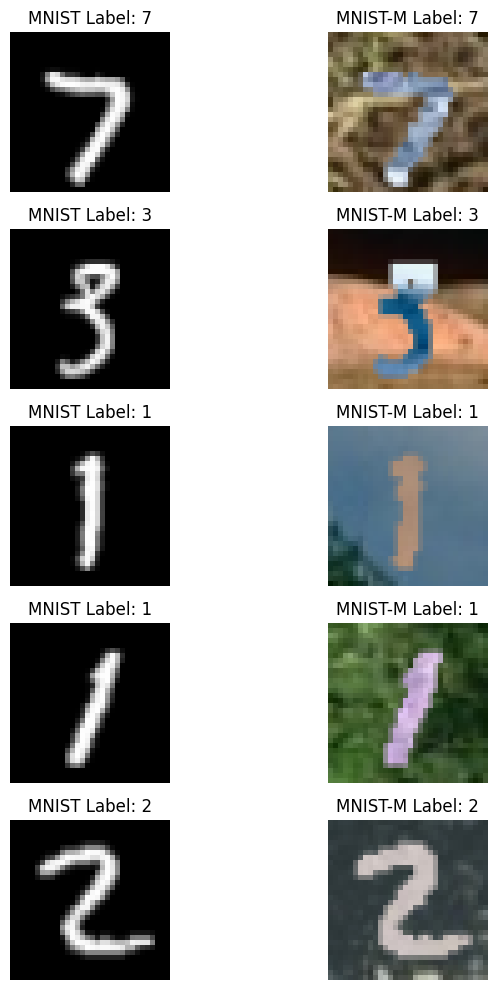

In [9]:
def visualize_paired_samples(mnist_train, mnistm_train, num_samples=5):
    """
    Visualize paired samples from MNIST and MNIST-M training sets.
    Each pair is sampled from the same index (preserving correspondence).
    """
    fig, axes = plt.subplots(num_samples, 2, figsize=(8, 2 * num_samples))
    for i in range(num_samples):
        # Get the i-th sample from each Subset
        mnist_img, mnist_lbl = mnist_train[i]
        mnistm_img, mnistm_lbl = mnistm_train[i]

        # Convert tensors to numpy for visualizationش
        axes[i, 0].imshow(mnist_img.permute(1, 2, 0).numpy() * 0.5 + 0.5)
        axes[i, 0].set_title(f"MNIST Label: {mnist_lbl}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mnistm_img.permute(1, 2, 0).numpy() * 0.5 + 0.5)
        axes[i, 1].set_title(f"MNIST-M Label: {mnistm_lbl}")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

# Example usage:
visualize_paired_samples(mnist_test, mnistm_test, num_samples=5)



<div dir="rtl">

#  مدل MNIST Classifier

<div dir="rtl">

## تعریف مدل  MNIST Classifier

In [90]:
class TaskClassifierMnist(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()

        # Feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels, 32, 5, padding=0),   # Output: 32 x 28 x 28
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),                  # Output: 32 x 14 x 14
            nn.Conv2d(32, 48, 5, padding=2),            # Output: 48 x 14 x 14
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),                  # Output: 48 x 7 x 7
        )

        # Classifier head
        self.cls = nn.Sequential(
            nn.Flatten(),
            nn.Linear(48 * 7 * 7, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, num_classes),
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.cls(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0.0, 0.02)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight, 1.0, 0.02)
                nn.init.constant_(m.bias, 0.0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                nn.init.constant_(m.bias, 0.0)


<div dir="rtl">

## تعریف توابع کمکی برای آموزش و ارزیابی مدل  MNIST Classifier

In [91]:
def train_one_epoch_mnist(classifier,
                          loader_s,
                          optimizer_T,
                          scheduler_T,
                          loss_ce,
                          metrics,
                          epoch=0,
                          device="cpu"):
    classifier.train()

    # Reset metrics
    for m in metrics.values():
        m.reset()

    # Training loop
    with tqdm(loader_s, total=len(loader_s), unit='batch', leave=True) as loop:
        loop.set_description(f"[MNIST] Epoch {epoch}")

        for x_s, y_s in loop:
            x_s, y_s = x_s.to(device), y_s.to(device)

            # Forward pass
            y_pred = classifier(x_s)

            # Classification loss
            loss = loss_ce(y_pred, y_s)

            # Backpropagation
            optimizer_T.zero_grad()
            loss.backward()
            optimizer_T.step()
            scheduler_T.step()

            # Update metrics
            metrics['loss_cls'].update(loss)
            metrics['acc_mnist_train'].update(y_pred, y_s)

            # Show metrics
            loop.set_postfix({
                "loss_cls": f"{metrics['loss_cls'].compute():.4f}",
                "acc_mnist_train": f"{metrics['acc_mnist_train'].compute():.2%}"
            })

    # Return final computed metrics
    return {name: m.compute().item() for name, m in metrics.items()}


In [92]:
def evaluate_mnist_classifier(classifier,
                              loader_mnist_test,
                              loader_mnistm_test,
                              loss_ce,
                              metrics,
                              device="cpu"):
    """
    Evaluate the classifier trained only on MNIST.
    Compute accuracy on MNIST test and full MNIST-M datasets.
    """
    classifier.eval()

    # Reset all metrics
    for m in metrics.values():
        m.reset()

    with torch.no_grad():
        # Evaluate on MNIST test set
        for x_mnist, y_mnist in loader_mnist_test:
            x_mnist, y_mnist = x_mnist.to(device), y_mnist.to(device)
            y_pred_mnist = classifier(x_mnist)
            loss = loss_ce(y_pred_mnist, y_mnist)
            metrics['loss_cls'].update(loss)
            metrics['acc_mnist_test'].update(y_pred_mnist, y_mnist)

        # Evaluate on full MNIST-M set
        for x_mnistm, y_mnistm in loader_mnistm_test:
            x_mnistm, y_mnistm = x_mnistm.to(device), y_mnistm.to(device)
            y_pred_mnistm = classifier(x_mnistm)  # domain is synthetic
            metrics['acc_mnistm_test'].update(y_pred_mnistm, y_mnistm)

    return {name: m.compute().item() for name, m in metrics.items()}


<div dir="rtl">

## فراخونی مدل MNIST Classifier و تنظیمات آموزش مدل

In [93]:
classifier_mnist = TaskClassifierMnist().to(device)

lr = 1e-3
betas = (0.5, 0.999)  # from paper Appendix B

loss_fn = nn.CrossEntropyLoss()  # for Task Classifier

optimizer_T_mnist = optim.Adam(classifier_mnist.parameters(), lr=lr, betas=betas)
scheduler_T_mnist = optim.lr_scheduler.StepLR(optimizer_T_mnist, step_size=20000, gamma=0.95)


In [94]:
# Define evaluation metrics for MNIST-only trained classifier
metrics_mnist = {
    'loss_cls': MeanMetric().to(device),
    'acc_mnist_train': Accuracy(task="multiclass", num_classes=10).to(device),
}

metrics_eval_mnist = {
    'loss_cls': MeanMetric().to(device),
    'acc_mnist_test': Accuracy(task="multiclass", num_classes=10).to(device),
    'acc_mnistm_test': Accuracy(task="multiclass", num_classes=10).to(device),
}

<div dir="rtl">

## آموزش مدل MNIST Classifier

In [95]:
num_epochs = 10
# ============
# Logs
# ============
train_mnist_log = []
eval_mnist_log = []


In [96]:
# ============
# Training Loop (MNIST-only classifier)
# ============
for epoch in range(1, num_epochs + 1):
    print(f"\n🔁 Epoch {epoch}/{num_epochs}")

    # === Train on MNIST only ===
    train_stats = train_one_epoch_mnist(
        classifier=classifier_mnist,
        loader_s=mnist_train_loader,
        optimizer_T=optimizer_T_mnist,
        scheduler_T=scheduler_T_mnist,
        loss_ce=loss_fn,
        metrics=metrics_mnist,
        epoch=epoch,
        device=device
    )
    train_stats["epoch"] = epoch
    train_mnist_log.append(train_stats)

    # === Evaluate on MNIST test and MNIST-M test ===
    eval_stats = evaluate_mnist_classifier(
        classifier=classifier_mnist,
        loader_mnist_test=mnist_test_loader,
        loader_mnistm_test=mnistm_test_loader,
        loss_ce=loss_fn,
        metrics=metrics_eval_mnist,
        device=device
    )
    eval_stats["epoch"] = epoch
    eval_mnist_log.append(eval_stats)

    # === Print evaluation results ===
    print("\n📊 Evaluation Metrics:")
    for k, v in eval_stats.items():
        if k == "epoch":
            continue
        if "acc" in k:
            print(f"✅ {k}: {v:.2%}")
        else:
            print(f"📉 {k}: {v:.4f}")



🔁 Epoch 1/10


[MNIST] Epoch 1: 100%|██████████| 1750/1750 [00:10<00:00, 161.43batch/s, loss_cls=0.1517, acc_mnist_train=95.21%]



📊 Evaluation Metrics:
📉 loss_cls: 0.0518
✅ acc_mnist_test: 98.37%
✅ acc_mnistm_test: 63.21%

🔁 Epoch 2/10


[MNIST] Epoch 2: 100%|██████████| 1750/1750 [00:10<00:00, 160.07batch/s, loss_cls=0.0487, acc_mnist_train=98.50%]



📊 Evaluation Metrics:
📉 loss_cls: 0.0648
✅ acc_mnist_test: 98.21%
✅ acc_mnistm_test: 62.32%

🔁 Epoch 3/10


...


📊 Evaluation Metrics:
📉 loss_cls: 0.0551
✅ acc_mnist_test: 98.89%
✅ acc_mnistm_test: 62.38%

🔁 Epoch 9/10


[MNIST] Epoch 9: 100%|██████████| 1750/1750 [00:10<00:00, 161.59batch/s, loss_cls=0.0149, acc_mnist_train=99.62%]



📊 Evaluation Metrics:
📉 loss_cls: 0.0438
✅ acc_mnist_test: 99.06%
✅ acc_mnistm_test: 61.59%

🔁 Epoch 10/10


[MNIST] Epoch 10: 100%|██████████| 1750/1750 [00:10<00:00, 162.18batch/s, loss_cls=0.0137, acc_mnist_train=99.61%]



📊 Evaluation Metrics:
📉 loss_cls: 0.0488
✅ acc_mnist_test: 98.97%
✅ acc_mnistm_test: 62.32%


<div dir="rtl">

## ارزیابی مدل MNIST Classifier

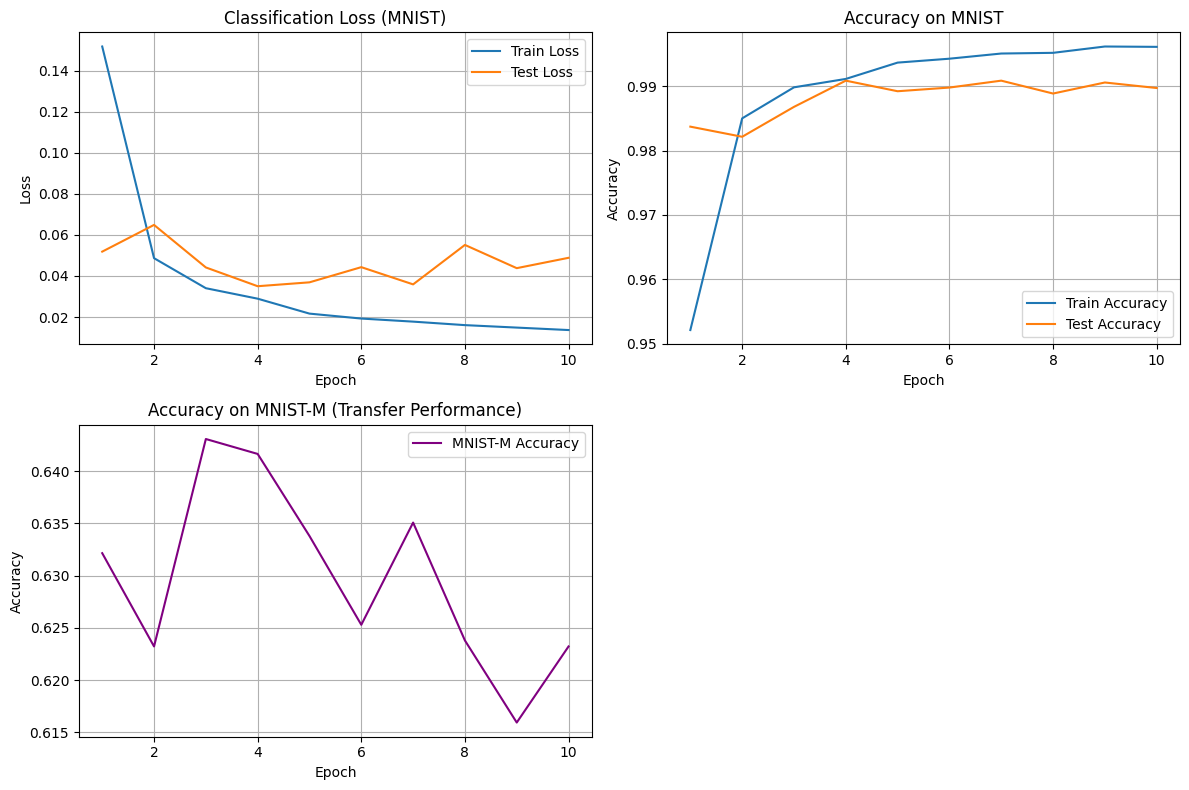

In [97]:
def plot_mnist_only_logs(train_log, eval_log):
    epochs = [entry["epoch"] for entry in train_log]

    # Extract values
    train_loss = [entry["loss_cls"] for entry in train_log]
    eval_loss = [entry["loss_cls"] for entry in eval_log]
    train_acc = [entry["acc_mnist_train"] for entry in train_log]
    eval_acc = [entry["acc_mnist_test"] for entry in eval_log]
    eval_acc_mnistm = [entry["acc_mnistm_test"] for entry in eval_log]

    # Plot
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    # Top-left: Loss
    axs[0, 0].plot(epochs, train_loss, label="Train Loss")
    axs[0, 0].plot(epochs, eval_loss, label="Test Loss")
    axs[0, 0].set_title("Classification Loss (MNIST)")
    axs[0, 0].set_xlabel("Epoch")
    axs[0, 0].set_ylabel("Loss")
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # Top-right: Accuracy (MNIST)
    axs[0, 1].plot(epochs, train_acc, label="Train Accuracy")
    axs[0, 1].plot(epochs, eval_acc, label="Test Accuracy")
    axs[0, 1].set_title("Accuracy on MNIST")
    axs[0, 1].set_xlabel("Epoch")
    axs[0, 1].set_ylabel("Accuracy")
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # Bottom-left: Accuracy on MNIST-M
    axs[1, 0].plot(epochs, eval_acc_mnistm, color="purple", label="MNIST-M Accuracy")
    axs[1, 0].set_title("Accuracy on MNIST-M (Transfer Performance)")
    axs[1, 0].set_xlabel("Epoch")
    axs[1, 0].set_ylabel("Accuracy")
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # Bottom-right: Leave empty
    axs[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Example usage:
plot_mnist_only_logs(train_mnist_log, eval_mnist_log)


In [98]:
# === Evaluate on MNIST test and all of MNIST-M  ===
eval_stats = evaluate_mnist_classifier(
    classifier=classifier_mnist,
    loader_mnist_test=mnist_test_loader,
    loader_mnistm_test=mnistm_loader,
    loss_ce=loss_fn,
    metrics=metrics_eval_mnist,
    device=device
)

# === Print evaluation results ===
print("\n📊 Evaluation Metrics:")
for k, v in eval_stats.items():
    if "acc_mnistm_test" in k:
        print(f"✅ acc_mnistm_all: {v:.2%}")



📊 Evaluation Metrics:
✅ acc_mnistm_all: 62.76%


<div dir="rtl">

# مدل MNISTM Classifier

<div dir="rtl">

## تعریف مدل  MNISTM Classifier

In [99]:
class TaskClassifierMnistm(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()

        # Feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels, 32, 5, padding=0),   # Output: 32 x 28 x 28
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),                  # Output: 32 x 14 x 14
            nn.Conv2d(32, 48, 5, padding=2),            # Output: 48 x 14 x 14
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),                  # Output: 48 x 7 x 7
        )

        # Classifier head
        self.cls = nn.Sequential(
            nn.Flatten(),
            nn.Linear(48 * 7 * 7, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, num_classes),
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.cls(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0.0, 0.02)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight, 1.0, 0.02)
                nn.init.constant_(m.bias, 0.0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                nn.init.constant_(m.bias, 0.0)


<div dir="rtl">

## تعریف توابع کمکی برای آموزش و ارزیابی مدل  MNISTM Classifier

In [100]:
def train_one_epoch_mnistm(classifier,
                          loader_s,
                          optimizer_T,
                          scheduler_T,
                          loss_ce,
                          metrics,
                          epoch=0,
                          device="cpu"):
    classifier.train()

    # Reset metrics
    for m in metrics.values():
        m.reset()

    # Training loop
    with tqdm(loader_s, total=len(loader_s), unit='batch', leave=True) as loop:
        loop.set_description(f"[MNISTM] Epoch {epoch}")

        for x_s, y_s in loop:
            x_s, y_s = x_s.to(device), y_s.to(device)

            # Forward pass
            y_pred = classifier(x_s)

            # Classification loss
            loss = loss_ce(y_pred, y_s)

            # Backpropagation
            optimizer_T.zero_grad()
            loss.backward()
            optimizer_T.step()
            scheduler_T.step()

            # Update metrics
            metrics['loss_cls'].update(loss)
            metrics['acc_mnistm_train'].update(y_pred, y_s)

            # Show metrics
            loop.set_postfix({
                "loss_cls": f"{metrics['loss_cls'].compute():.4f}",
                "acc_mnistm_train": f"{metrics['acc_mnistm_train'].compute():.2%}"
            })

    # Return final computed metrics
    return {name: m.compute().item() for name, m in metrics.items()}


In [101]:
def evaluate_mnistm_classifier(classifier,
                              loader_mnistm_test,
                              loss_ce,
                              metrics,
                              device="cpu"):
    """
    Evaluate the classifier trained only on MNISTM.
    """
    classifier.eval()

    # Reset all metrics
    for m in metrics.values():
        m.reset()

    with torch.no_grad():
        # Evaluate on MNISTM test set
        for x_mnist, y_mnist in loader_mnistm_test:
            x_mnist, y_mnist = x_mnist.to(device), y_mnist.to(device)
            y_pred_mnist = classifier(x_mnist)
            loss = loss_ce(y_pred_mnist, y_mnist)
            metrics['loss_cls'].update(loss)
            metrics['acc_mnistm_test'].update(y_pred_mnist, y_mnist)



    return {name: m.compute().item() for name, m in metrics.items()}


<div dir="rtl">

## فراخونی مدل MNISTM Classifier و تنظیمات آموزش مدل

In [102]:
classifier_mnistm = TaskClassifierMnistm().to(device)

lr = 1e-3
betas = (0.5, 0.999)  # from paper Appendix B

loss_fn = nn.CrossEntropyLoss()  # for Task Classifier

optimizer_T_mnistm = optim.Adam(classifier_mnistm.parameters(), lr=lr, betas=betas)
scheduler_T_mnistm = optim.lr_scheduler.StepLR(optimizer_T_mnistm, step_size=20000, gamma=0.95)


In [103]:
# Define evaluation metrics for MNISTM-only trained classifier
metrics_mnistm = {
    'loss_cls': MeanMetric().to(device),
    'acc_mnistm_train': Accuracy(task="multiclass", num_classes=10).to(device),
}

metrics_eval_mnistm = {
    'loss_cls': MeanMetric().to(device),
    'acc_mnistm_test': Accuracy(task="multiclass", num_classes=10).to(device),
}

<div dir="rtl">

## آموزش مدل MNISTM Classifier

In [104]:
num_epochs = 10

# ============
# Logs
# ============
train_mnistm_log = []
eval_mnistm_log = []


In [105]:
# ============
# Training Loop (MNIST-only classifier)
# ============
for epoch in range(1, num_epochs + 1):
    print(f"\n🔁 Epoch {epoch}/{num_epochs}")

    # === Train on MNIST only ===
    train_stats = train_one_epoch_mnistm(
        classifier=classifier_mnistm,
        loader_s=mnistm_train_loader,
        optimizer_T=optimizer_T_mnistm,
        scheduler_T=scheduler_T_mnistm,
        loss_ce=loss_fn,
        metrics=metrics_mnistm,
        epoch=epoch,
        device=device
    )
    train_stats["epoch"] = epoch
    train_mnistm_log.append(train_stats)

    # === Evaluate on MNIST test and MNIST-M test ===
    eval_stats = evaluate_mnistm_classifier(
        classifier=classifier_mnistm,
        loader_mnistm_test=mnistm_test_loader,
        loss_ce=loss_fn,
        metrics=metrics_eval_mnistm,
        device=device
    )
    eval_stats["epoch"] = epoch
    eval_mnistm_log.append(eval_stats)

    # === Print evaluation results ===
    print("\n📊 Evaluation Metrics:")
    for k, v in eval_stats.items():
        if k == "epoch":
            continue
        if "acc" in k:
            print(f"✅ {k}: {v:.2%}")
        else:
            print(f"📉 {k}: {v:.4f}")



🔁 Epoch 1/10


[MNISTM] Epoch 1: 100%|██████████| 1750/1750 [00:10<00:00, 161.78batch/s, loss_cls=0.3788, acc_mnistm_train=87.88%]



📊 Evaluation Metrics:
📉 loss_cls: 0.2116
✅ acc_mnistm_test: 93.18%

🔁 Epoch 2/10


[MNISTM] Epoch 2: 100%|██████████| 1750/1750 [00:10<00:00, 159.84batch/s, loss_cls=0.1487, acc_mnistm_train=95.35%]



📊 Evaluation Metrics:
📉 loss_cls: 0.1639
✅ acc_mnistm_test: 95.07%

🔁 Epoch 3/10


...


📊 Evaluation Metrics:
📉 loss_cls: 0.1618
✅ acc_mnistm_test: 96.26%

🔁 Epoch 9/10


[MNISTM] Epoch 9: 100%|██████████| 1750/1750 [00:10<00:00, 161.37batch/s, loss_cls=0.0372, acc_mnistm_train=98.88%]



📊 Evaluation Metrics:
📉 loss_cls: 0.1818
✅ acc_mnistm_test: 96.04%

🔁 Epoch 10/10


[MNISTM] Epoch 10: 100%|██████████| 1750/1750 [00:10<00:00, 161.44batch/s, loss_cls=0.0335, acc_mnistm_train=98.93%]



📊 Evaluation Metrics:
📉 loss_cls: 0.1985
✅ acc_mnistm_test: 96.11%


<div dir="rtl">

## ارزیابی مدل MNISTM Classifier

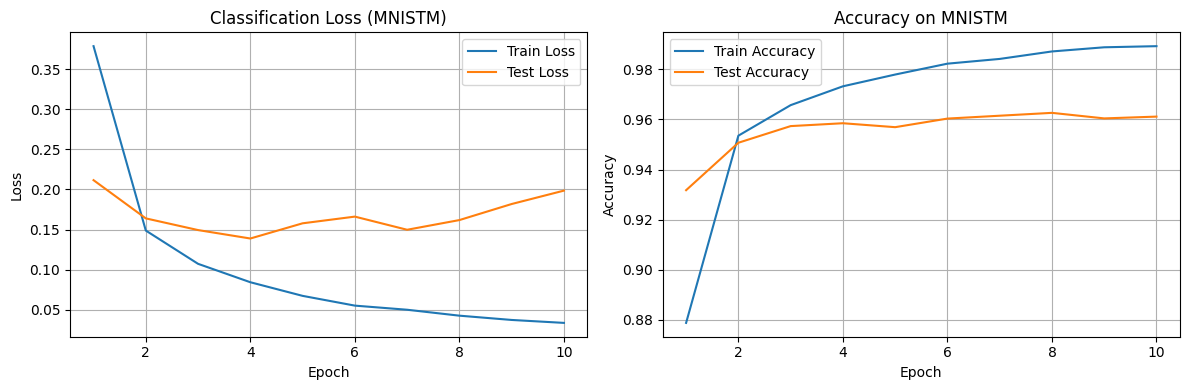

In [106]:
def plot_mnistm_only_logs(train_log, eval_log):
    epochs = [entry["epoch"] for entry in train_log]

    # Extract values
    train_loss = [entry["loss_cls"] for entry in train_log]
    eval_loss = [entry["loss_cls"] for entry in eval_log]
    train_acc = [entry["acc_mnistm_train"] for entry in train_log]
    eval_acc = [entry["acc_mnistm_test"] for entry in eval_log]

    # Plot
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Top-left: Loss
    axs[0].plot(epochs, train_loss, label="Train Loss")
    axs[0].plot(epochs, eval_loss, label="Test Loss")
    axs[0].set_title("Classification Loss (MNISTM)")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].legend()
    axs[0].grid(True)

    # Top-right: Accuracy (MNISTM)
    axs[1].plot(epochs, train_acc, label="Train Accuracy")
    axs[1].plot(epochs, eval_acc, label="Test Accuracy")
    axs[1].set_title("Accuracy on MNISTM")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].legend()
    axs[1].grid(True)



    plt.tight_layout()
    plt.show()

# Example usage:
plot_mnistm_only_logs(train_mnistm_log, eval_mnistm_log)


In [107]:
# === Evaluate on MNISTM test and all of MNIST-M  ===
eval_stats = evaluate_mnistm_classifier(
    classifier=classifier_mnistm,
    loader_mnistm_test=mnistm_loader,
    loss_ce=loss_fn,
    metrics=metrics_eval_mnist,
    device=device
)

# === Print evaluation results ===
print("\n📊 Evaluation Metrics:")
for k, v in eval_stats.items():
    if "acc_mnistm_test" in k:
        print(f"✅ acc_mnistm_all: {v:.2%}")



📊 Evaluation Metrics:
✅ acc_mnistm_all: 98.38%


<div dir="rtl">

# مدل PixelDA

<div dir="rtl">

## تعریف مدل ها

<div dir="rtl">

### تعریف مدل Geneator

In [10]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, input_channels=3, output_channels=3, z_dim=10):
        super().__init__()
        self.z_dim = z_dim
        self.fc_z = nn.Linear(z_dim, 32 * 32)  # project z to spatial map

        self.input_conv = nn.Conv2d(input_channels + 1, 64, 3, padding=1)

        self.res_blocks = nn.Sequential(*[ResidualBlock(64) for _ in range(6)])

        self.output_conv = nn.Sequential(
            nn.Conv2d(64, output_channels, 3, padding=1),
            nn.Tanh()
        )

        self._initialize_weights()

    def forward(self, x, z):
        z = self.fc_z(z).view(-1, 1, 32, 32)
        x = torch.cat([x, z], dim=1)
        x = self.input_conv(x)
        x = self.res_blocks(x)
        return self.output_conv(x)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0.0, 0.02)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight, 1.0, 0.02)
                nn.init.constant_(m.bias, 0.0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                nn.init.constant_(m.bias, 0.0)


<div dir="rtl">

### تعریف مدل Discriminator

In [11]:
class Discriminator(nn.Module):
    def __init__(self, input_channels=3, noise_std=0.2, dropout_p=0.1):
        super().__init__()
        self.noise_std = noise_std
        self.dropout_p = dropout_p

        self.conv1 = nn.Conv2d(input_channels, 64, 3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)
        self.conv4 = nn.Conv2d(256, 512, 3, stride=2, padding=1)

        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(256)
        self.bn4 = nn.BatchNorm2d(512)

        self.drop = nn.Dropout(p=self.dropout_p)
        self.fc = nn.Linear(512 * 4 * 4, 1)

        self._initialize_weights()

    def forward(self, x):
        x = self._inject_noise(self.conv1(x))
        x = self.drop(F.leaky_relu(x, 0.2))

        x = self._inject_noise(self.bn2(self.conv2(x)))
        x = self.drop(F.leaky_relu(x, 0.2))

        x = self._inject_noise(self.bn3(self.conv3(x)))
        x = self.drop(F.leaky_relu(x, 0.2))

        x = self._inject_noise(self.bn4(self.conv4(x)))
        x = self.drop(F.leaky_relu(x, 0.2))

        x = x.view(x.size(0), -1)
        return torch.sigmoid(self.fc(x))

    def _inject_noise(self, x):
        if self.training:
            noise = torch.randn_like(x) * self.noise_std
            return x + noise
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0.0, 0.02)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight, 1.0, 0.02)
                nn.init.constant_(m.bias, 0.0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                nn.init.constant_(m.bias, 0.0)


<div dir="rtl">

### تعریف مدل TaskClassifier

In [12]:
class TaskClassifier(nn.Module):
    def __init__(self, in_channels_synthetic=3, in_channels_generated=3, num_classes=10):
        super().__init__()

        self.private_synthetic = nn.Sequential(
            nn.Conv2d(in_channels_synthetic, 32, 5, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2)
        )

        self.private_generated = nn.Sequential(
            nn.Conv2d(in_channels_generated, 32, 5, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2)
        )

        self.shared = nn.Sequential(
            nn.Conv2d(32, 48, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
            nn.Flatten(),
            nn.Linear(48 * 7 * 7, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, num_classes),
        )

        self._initialize_weights()

    def forward(self, x, domain='synthetic'):
        if domain == 'synthetic':
            x = self.private_synthetic(x)
        elif domain == 'generated':
            x = self.private_generated(x)
        else:
            raise ValueError("domain must be 'synthetic' or 'generated'")
        return self.shared(x)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0.0, 0.02)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight, 1.0, 0.02)
                nn.init.constant_(m.bias, 0.0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                nn.init.constant_(m.bias, 0.0)


<div dir="rtl">

## تعریف توابع مورد نیاز برای آموزش و ارزیابی مدل PixelDA

In [13]:

def train_one_epoch(generator, discriminator, classifier,
                    loader_s, loader_t,
                    optimizer_G, optimizer_D, optimizer_T,
                    scheduler_G, scheduler_D, scheduler_T,
                    loss_bce, loss_ce,
                    metrics, epoch=0,
                    z_dim = 10,  # match your generator config
                    device="cpu"):

    generator.train()
    discriminator.train()
    classifier.train()

    # Reset all metrics
    for m in metrics.values():
        m.reset()

    # Progress bar setup
    dataloop = zip(loader_s, loader_t)
    with tqdm(dataloader := dataloop, total=len(loader_s), unit='batch', leave=True) as loop:
        loop.set_description(f"Epoch {epoch}")

        for (x_s, y_s), (x_t, _) in loop:
            x_s, y_s = x_s.to(device), y_s.to(device)
            x_t = x_t.to(device)
            batch_size = x_s.size(0)
            z = torch.empty(batch_size, z_dim, device=device).uniform_(-1, 1)

            # === Generate fake images ===
            x_f = generator(x_s, z)

            # === Step 1: Train Discriminator ===
            optimizer_D.zero_grad()
            pred_real = discriminator(x_t)
            pred_fake = discriminator(x_f.detach())
            loss_d = 0.13 * (loss_bce(pred_real, torch.ones_like(pred_real)) +
                             loss_bce(pred_fake, torch.zeros_like(pred_fake)))
            loss_d.backward()
            optimizer_D.step()
            scheduler_D.step()
            metrics['loss_D'].update(loss_d)

            # === Step 2: Train Classifier ===
            optimizer_T.zero_grad()
            y_pred_s = classifier(x_s, domain='synthetic')
            y_pred_f = classifier(x_f.detach(), domain='generated')
            loss_t = (loss_ce(y_pred_s, y_s) + loss_ce(y_pred_f, y_s))
            loss_t.backward()
            optimizer_T.step()
            scheduler_T.step()
            metrics['loss_T'].update(loss_t)
            metrics['acc_synthetic'].update(y_pred_s, y_s)
            metrics['acc_generated'].update(y_pred_f, y_s)

            # === Step 3: Train Generator ===
            optimizer_G.zero_grad()
            x_f = generator(x_s, z)  # regenerate
            pred_fake = discriminator(x_f)
            adv_loss = 0.011 * loss_bce(pred_fake, torch.ones_like(pred_fake))
            y_pred_f = classifier(x_f, domain='generated')
            task_loss = 0.01 * loss_ce(y_pred_f, y_s)
            loss_g = adv_loss + task_loss
            loss_g.backward()
            optimizer_G.step()
            scheduler_G.step()
            metrics['loss_G'].update(loss_g)

            # Update progress bar
            loop.set_postfix({
                "loss_D": f"{metrics['loss_D'].compute():.4f}",
                "loss_T": f"{metrics['loss_T'].compute():.4f}",
                "loss_G": f"{metrics['loss_G'].compute():.4f}",
                "acc_src": f"{metrics['acc_synthetic'].compute():.2%}",
                "acc_gen": f"{metrics['acc_generated'].compute():.2%}"
            })

    # Final metrics
    return {name: m.compute().item() for name, m in metrics.items()}


In [14]:
def evaluate_one_epoch(generator, discriminator, classifier,
                       loader_s, loader_t,
                       loss_ce, loss_bce,
                       metrics,
                       z_dim=10,
                       device="cpu"):

    generator.eval()
    discriminator.eval()
    classifier.eval()

    # Reset all metrics
    for m in metrics.values():
        m.reset()

    with torch.no_grad():
        for (x_s, y_s), (x_t, y_t) in zip(loader_s, loader_t):
            x_s, y_s = x_s.to(device), y_s.to(device)
            x_t, y_t = x_t.to(device), y_t.to(device)
            batch_size = x_s.size(0)

            # Sample z from Uniform(-1, 1)
            z = torch.empty(batch_size, z_dim, device=device).uniform_(-1, 1)

            # Generate fake image
            x_f = generator(x_s, z)

            # Classifier predictions
            y_pred_s = classifier(x_s, domain='synthetic')
            y_pred_f = classifier(x_f, domain='generated')
            y_pred_t = classifier(x_t, domain='generated')

            # Accuracy
            metrics['acc_synthetic'].update(y_pred_s, y_s)
            metrics['acc_generated'].update(y_pred_f, y_s)
            metrics['acc_target_real'].update(y_pred_t, y_t)

            # Task classifier loss
            loss_t = loss_ce(y_pred_s, y_s) + loss_ce(y_pred_f, y_s)
            metrics['loss_T'].update(loss_t)

            # Generator loss
            pred_fake = discriminator(x_f)
            adv_loss = 0.011 * loss_bce(pred_fake, torch.ones_like(pred_fake))
            task_loss = 0.01 * loss_ce(y_pred_f, y_s)
            loss_g = adv_loss + task_loss
            metrics['loss_G'].update(loss_g)

            # Discriminator loss
            pred_real = discriminator(x_t)
            loss_d = 0.13 * (
                loss_bce(pred_real, torch.ones_like(pred_real)) +
                loss_bce(pred_fake, torch.zeros_like(pred_fake))
            )
            metrics['loss_D'].update(loss_d)

    return {name: m.compute().item() for name, m in metrics.items()}


In [15]:
def generate_images(generator, batch_images, z_dim=10, device="cpu"):
    """
    Generate and return denormalized images ready for visualization with matplotlib.

    Args:
        generator: trained Generator
        batch_images: (B, 3, 32, 32) tensor from DataLoader
        z_dim: latent dimension
        device: cuda or cpu

    Returns:
        Tuple of (originals, generated) tensors on CPU, denormalized to [0,1]
        Shape: (B, 3, 32, 32)
    """
    generator.eval()

    with torch.no_grad():
        x = batch_images.to(device)
        batch_size = x.size(0)
        z = torch.empty(batch_size, z_dim, device=device).uniform_(-1, 1)
        x_gen = generator(x, z)

    # Denormalize and move to CPU
    x_vis = x * 0.5 + 0.5
    x_gen_vis = x_gen * 0.5 + 0.5

    return x_vis.cpu(), x_gen_vis.cpu()


<div dir="rtl">

##      فراخوانی مدل PixelDA و تنظیمات آموزش مدل

In [16]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)
classifier = TaskClassifier().to(device)

lr = 1e-3
betas = (0.5, 0.999)  # from paper Appendix B

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=betas)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=betas)
optimizer_T = optim.Adam(classifier.parameters(), lr=lr, betas=betas)


loss_bce = nn.BCELoss()  # for Discriminator
loss_ce = nn.CrossEntropyLoss()  # for Task Classifier


# StepLR: decay by 0.95 every 20000 steps
scheduler_G = optim.lr_scheduler.StepLR(optimizer_G, step_size=20000, gamma=0.95)
scheduler_D = optim.lr_scheduler.StepLR(optimizer_D, step_size=20000, gamma=0.95)
scheduler_T = optim.lr_scheduler.StepLR(optimizer_T, step_size=20000, gamma=0.95)


In [17]:
metrics = {
    'loss_D': MeanMetric().to(device),
    'loss_G': MeanMetric().to(device),
    'loss_T': MeanMetric().to(device),
    'acc_synthetic': Accuracy(task="multiclass", num_classes=10).to(device),
    'acc_generated': Accuracy(task="multiclass", num_classes=10).to(device)
}


metrics_eval = {
    'loss_D': MeanMetric().to(device),
    'loss_G': MeanMetric().to(device),
    'loss_T': MeanMetric().to(device),
    'acc_synthetic': Accuracy(task="multiclass", num_classes=10).to(device),
    'acc_generated': Accuracy(task="multiclass", num_classes=10).to(device),
    'acc_target_real': Accuracy(task="multiclass", num_classes=10).to(device),
}


In [19]:
generator = torch.load('generator.pt', map_location=device, weights_only=False)
discriminator = torch.load('discriminator.pt', map_location=device, weights_only=False)
classifier = torch.load('classifier.pt', map_location=device, weights_only=False)

with open('train_log.pkl', 'rb') as f:
    train_log = pickle.load(f)

with open('eval_log.pkl', 'rb') as f:
    eval_log = pickle.load(f)


<div dir="rtl">

## آموزش مدل PixelDA

In [ ]:
num_epochs = 100
# ============
# Logs
# ============
train_log = []
eval_log = []



In [ ]:
# ============
# Training Loop
# ============
for epoch in range(1, num_epochs + 1):
    print(f"\n🔁 Epoch {epoch}/{num_epochs}")

    # === Train ===
    train_stats = train_one_epoch(
        generator, discriminator, classifier,
        loader_s=mnist_train_loader,
        loader_t=mnistm_train_loader,
        optimizer_G=optimizer_G,
        optimizer_D=optimizer_D,
        optimizer_T=optimizer_T,
        scheduler_G=scheduler_G,
        scheduler_D=scheduler_D,
        scheduler_T=scheduler_T,
        loss_bce=loss_bce,
        loss_ce=loss_ce,
        metrics=metrics,
        epoch=epoch,
        z_dim=10,
        device=device
    )
    train_stats["epoch"] = epoch
    train_log.append(train_stats)

    # === Evaluate ===
    eval_stats = evaluate_one_epoch(
        generator, discriminator, classifier,
        loader_s=mnist_test_loader,
        loader_t=mnistm_test_loader,
        loss_ce=loss_ce,
        loss_bce=loss_bce,
        metrics=metrics_eval,
        z_dim=10,
        device=device
    )
    eval_stats["epoch"] = epoch
    eval_log.append(eval_stats)

    # === Print ===
    print("\n📊 Evaluation Metrics:")
    for k, v in eval_stats.items():
        if k == "epoch":
            continue
        if "acc" in k:
            print(f"✅ {k}: {v:.2%}")
        else:
            print(f"📉 {k}: {v:.4f}")



🔁 Epoch 1/100


Epoch 1: 100%|██████████| 1750/1750 [01:02<00:00, 27.79batch/s, loss_D=0.1617, loss_T=0.4824, loss_G=0.0245, acc_src=94.79%, acc_gen=89.84%]



📊 Evaluation Metrics:
📉 loss_D: 0.1320
📉 loss_G: 0.0147
📉 loss_T: 0.4915
✅ acc_synthetic: 97.74%
✅ acc_generated: 86.19%
✅ acc_target_real: 85.53%

🔁 Epoch 2/100


Epoch 2: 100%|██████████| 1750/1750 [01:03<00:00, 27.44batch/s, loss_D=0.1233, loss_T=0.1832, loss_G=0.0287, acc_src=98.52%, acc_gen=95.81%]



📊 Evaluation Metrics:
📉 loss_D: 0.1631
📉 loss_G: 0.0105
📉 loss_T: 0.1686
✅ acc_synthetic: 98.24%
✅ acc_generated: 96.54%
✅ acc_target_real: 90.90%

🔁 Epoch 3/100


...


📊 Evaluation Metrics:
📉 loss_D: 0.2474
📉 loss_G: 0.0338
📉 loss_T: 0.2584
✅ acc_synthetic: 99.16%
✅ acc_generated: 98.64%
✅ acc_target_real: 98.07%

🔁 Epoch 99/100


Epoch 99: 100%|██████████| 1750/1750 [01:04<00:00, 26.96batch/s, loss_D=0.0263, loss_T=0.0322, loss_G=0.0881, acc_src=99.96%, acc_gen=99.09%]



📊 Evaluation Metrics:
📉 loss_D: 0.5987
📉 loss_G: 0.0689
📉 loss_T: 0.2560
✅ acc_synthetic: 99.26%
✅ acc_generated: 98.49%
✅ acc_target_real: 98.09%

🔁 Epoch 100/100


Epoch 100: 100%|██████████| 1750/1750 [01:04<00:00, 27.05batch/s, loss_D=0.0229, loss_T=0.0277, loss_G=0.0914, acc_src=99.99%, acc_gen=99.20%]



📊 Evaluation Metrics:
📉 loss_D: 0.1444
📉 loss_G: 0.0222
📉 loss_T: 0.2306
✅ acc_synthetic: 99.26%
✅ acc_generated: 98.72%
✅ acc_target_real: 97.85%


In [ ]:
# ============
# Training Loop
# ============
for epoch in range(101, 150):
    print(f"\n🔁 Epoch {epoch}/{num_epochs}")

    # === Train ===
    train_stats = train_one_epoch(
        generator, discriminator, classifier,
        loader_s=mnist_train_loader,
        loader_t=mnistm_train_loader,
        optimizer_G=optimizer_G,
        optimizer_D=optimizer_D,
        optimizer_T=optimizer_T,
        scheduler_G=scheduler_G,
        scheduler_D=scheduler_D,
        scheduler_T=scheduler_T,
        loss_bce=loss_bce,
        loss_ce=loss_ce,
        metrics=metrics,
        epoch=epoch,
        z_dim=10,
        device=device
    )
    train_stats["epoch"] = epoch
    train_log.append(train_stats)

    # === Evaluate ===
    eval_stats = evaluate_one_epoch(
        generator, discriminator, classifier,
        loader_s=mnist_test_loader,
        loader_t=mnistm_test_loader,
        loss_ce=loss_ce,
        loss_bce=loss_bce,
        metrics=metrics_eval,
        z_dim=10,
        device=device
    )
    eval_stats["epoch"] = epoch
    eval_log.append(eval_stats)

    # === Print ===
    print("\n📊 Evaluation Metrics:")
    for k, v in eval_stats.items():
        if k == "epoch":
            continue
        if "acc" in k:
            print(f"✅ {k}: {v:.2%}")
        else:
            print(f"📉 {k}: {v:.4f}")



🔁 Epoch 101/100


Epoch 101: 100%|██████████| 1750/1750 [01:05<00:00, 26.79batch/s, loss_D=0.0242, loss_T=0.0378, loss_G=0.0903, acc_src=99.97%, acc_gen=99.01%]



📊 Evaluation Metrics:
📉 loss_D: 0.4130
📉 loss_G: 0.0519
📉 loss_T: 0.3111
✅ acc_synthetic: 99.25%
✅ acc_generated: 97.06%
✅ acc_target_real: 98.01%

🔁 Epoch 102/100


Epoch 102: 100%|██████████| 1750/1750 [01:05<00:00, 26.81batch/s, loss_D=0.0253, loss_T=0.0387, loss_G=0.0932, acc_src=99.96%, acc_gen=98.96%]



📊 Evaluation Metrics:
📉 loss_D: 0.1629
📉 loss_G: 0.0220
📉 loss_T: 0.2241
✅ acc_synthetic: 99.31%
✅ acc_generated: 98.61%
✅ acc_target_real: 98.04%

🔁 Epoch 103/100


...


📊 Evaluation Metrics:
📉 loss_D: 0.2065
📉 loss_G: 0.0307
📉 loss_T: 0.3074
✅ acc_synthetic: 99.24%
✅ acc_generated: 98.61%
✅ acc_target_real: 98.21%

🔁 Epoch 148/100


Epoch 148: 100%|██████████| 1750/1750 [01:05<00:00, 26.65batch/s, loss_D=0.0211, loss_T=0.0271, loss_G=0.0903, acc_src=99.99%, acc_gen=99.23%]



📊 Evaluation Metrics:
📉 loss_D: 0.2816
📉 loss_G: 0.0368
📉 loss_T: 0.2491
✅ acc_synthetic: 99.32%
✅ acc_generated: 98.59%
✅ acc_target_real: 98.32%

🔁 Epoch 149/100


Epoch 149: 100%|██████████| 1750/1750 [01:05<00:00, 26.60batch/s, loss_D=0.0228, loss_T=0.0339, loss_G=0.0905, acc_src=99.98%, acc_gen=99.06%]



📊 Evaluation Metrics:
📉 loss_D: 0.1759
📉 loss_G: 0.0132
📉 loss_T: 0.2850
✅ acc_synthetic: 99.24%
✅ acc_generated: 98.46%
✅ acc_target_real: 98.20%


<div dir="rtl">

## ذخیره مدل PixelDA

In [ ]:
torch.save(generator, 'generator.pt')
torch.save(discriminator, 'discriminator.pt')
torch.save(classifier, 'classifier.pt')

In [ ]:
with open('train_log.pkl', 'wb') as f:
    pickle.dump(train_log, f)

with open('eval_log.pkl', 'wb') as f:
    pickle.dump(eval_log, f)


<div dir="rtl">

## ارزیابی مدل PixelDA

In [ ]:
def visualize_generated_images_with_mnistm(generator, loader_mnist, loader_mnistm, z_dim=10, device='cpu', num_samples=20):
    """
    Visualize original MNIST, generated MNIST-M-like, and real MNIST-M images.
    Each sample has 3 versions shown side-by-side: Original, Generated, MNIST-M.
    """
    # Get corresponding batches from both loaders
    for (x_mnist, _), (x_mnistm, _) in zip(loader_mnist, loader_mnistm):
        x_mnist = x_mnist[:num_samples]
        x_mnistm = x_mnistm[:num_samples]
        break

    # Generate images from MNIST
    x_gen_orig, x_gen_fake = generate_images(generator, x_mnist, z_dim=z_dim, device=device)

    # Denormalize MNIST-M manually
    x_mnistm_vis = x_mnistm * 0.5 + 0.5
    x_mnistm_vis = x_mnistm_vis.cpu()

    # Plotting
    fig, axes = plt.subplots(num_samples, 3, figsize=(9, 3 * num_samples))
    for i in range(num_samples):
        axes[i, 0].imshow(x_gen_orig[i].permute(1, 2, 0).numpy())
        axes[i, 0].set_title("Original MNIST")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(x_gen_fake[i].permute(1, 2, 0).numpy())
        axes[i, 1].set_title("Generated")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(x_mnistm_vis[i].permute(1, 2, 0).numpy())
        axes[i, 2].set_title("Real MNIST-M")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()


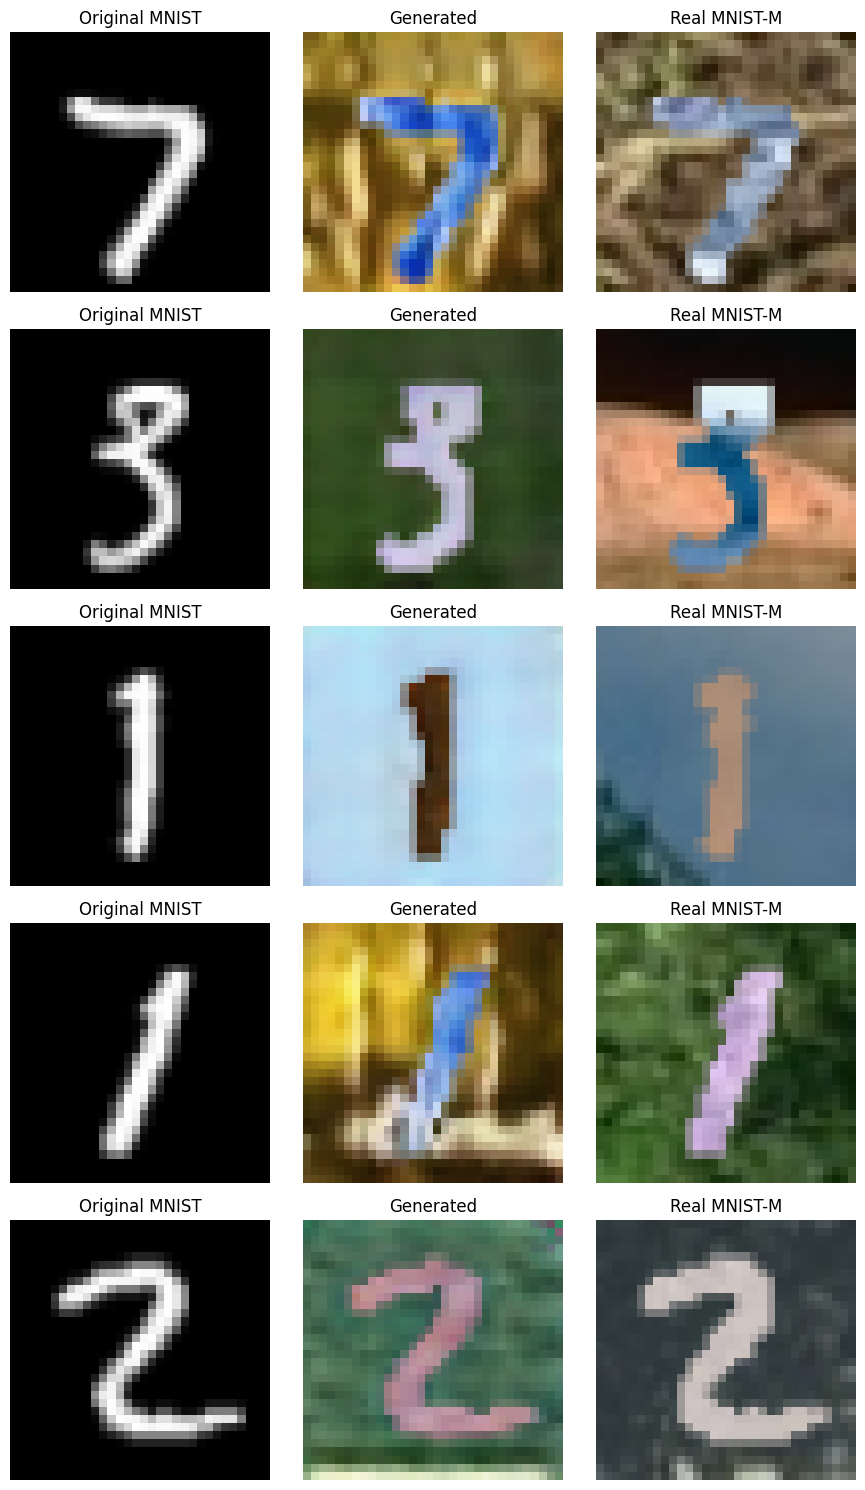

In [ ]:
visualize_generated_images_with_mnistm(
    generator,
    loader_mnist=mnist_test_loader,
    loader_mnistm=mnistm_test_loader,
    z_dim=10,
    device=device,
    num_samples=5
)


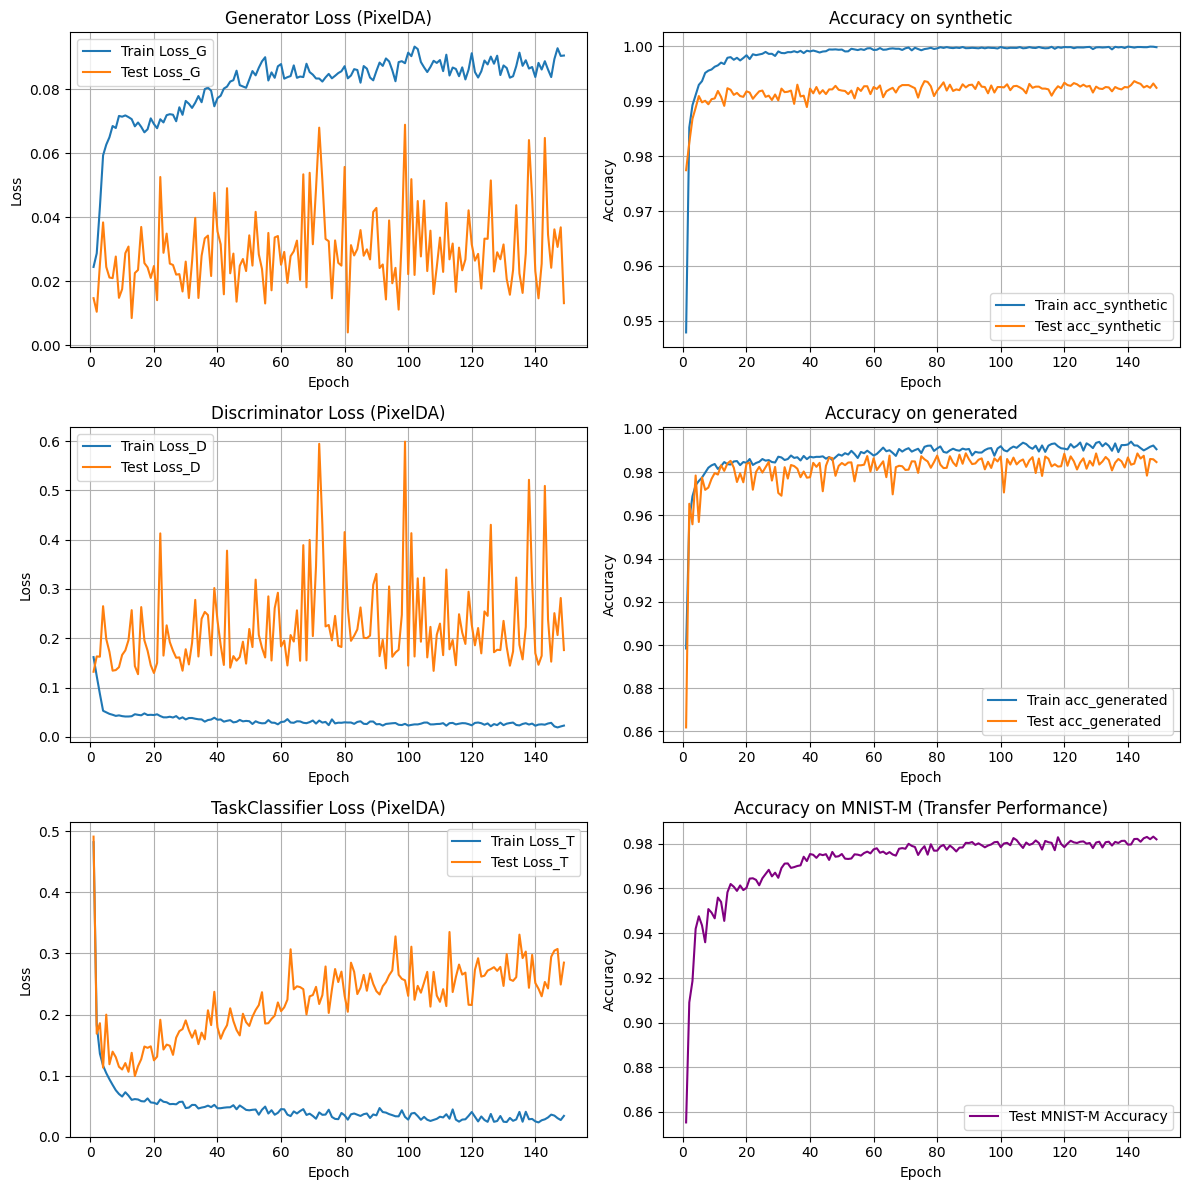

In [28]:
def plot_PixelDA_logs(train_log, eval_log):
    epochs = [entry["epoch"] for entry in train_log]

    # Extract values
    train_loss_D = [entry["loss_D"] for entry in train_log]
    eval_loss_D = [entry["loss_D"] for entry in eval_log]
    train_loss_G = [entry["loss_G"] for entry in train_log]
    eval_loss_G = [entry["loss_G"] for entry in eval_log]
    train_loss_T = [entry["loss_T"] for entry in train_log]
    eval_loss_T = [entry["loss_T"] for entry in eval_log]

    train_acc_src = [entry["acc_synthetic"] for entry in train_log]
    eval_acc_src = [entry["acc_synthetic"] for entry in eval_log]
    train_acc_gen = [entry["acc_generated"] for entry in train_log]
    eval_acc_gen = [entry["acc_generated"] for entry in eval_log]

    eval_acc_mnistm = [entry["acc_target_real"] for entry in eval_log]

    # Plot
    fig, axs = plt.subplots(3, 2, figsize=(12, 12))

    axs[0, 0].plot(epochs, train_loss_G, label="Train Loss_G")
    axs[0, 0].plot(epochs, eval_loss_G, label="Test Loss_G")
    axs[0, 0].set_title("Generator Loss (PixelDA)")
    axs[0, 0].set_xlabel("Epoch")
    axs[0, 0].set_ylabel("Loss")
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    axs[1, 0].plot(epochs, train_loss_D, label="Train Loss_D")
    axs[1, 0].plot(epochs, eval_loss_D, label="Test Loss_D")
    axs[1, 0].set_title("Discriminator Loss (PixelDA)")
    axs[1, 0].set_xlabel("Epoch")
    axs[1, 0].set_ylabel("Loss")
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    axs[2, 0].plot(epochs, train_loss_T, label="Train Loss_T")
    axs[2, 0].plot(epochs, eval_loss_T, label="Test Loss_T")
    axs[2, 0].set_title("TaskClassifier Loss (PixelDA)")
    axs[2, 0].set_xlabel("Epoch")
    axs[2, 0].set_ylabel("Loss")
    axs[2, 0].legend()
    axs[2, 0].grid(True)


    axs[0, 1].plot(epochs, train_acc_src, label="Train acc_synthetic")
    axs[0, 1].plot(epochs, eval_acc_src, label="Test acc_synthetic")
    axs[0, 1].set_title("Accuracy on synthetic")
    axs[0, 1].set_xlabel("Epoch")
    axs[0, 1].set_ylabel("Accuracy")
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    axs[1, 1].plot(epochs, train_acc_gen, label="Train acc_generated")
    axs[1, 1].plot(epochs, eval_acc_gen, label="Test acc_generated")
    axs[1, 1].set_title("Accuracy on generated")
    axs[1, 1].set_xlabel("Epoch")
    axs[1, 1].set_ylabel("Accuracy")
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    axs[2, 1].plot(epochs, eval_acc_mnistm, color="purple", label="Test MNIST-M Accuracy")
    axs[2, 1].set_title("Accuracy on MNIST-M (Transfer Performance)")
    axs[2, 1].set_xlabel("Epoch")
    axs[2, 1].set_ylabel("Accuracy")
    axs[2, 1].legend()
    axs[2, 1].grid(True)

    plt.tight_layout()
    plt.show()

# Example usage:
plot_PixelDA_logs(train_log, eval_log)


In [29]:
# === Evaluate on MNISTM test and all of MNIST-M  ===
eval_stats = evaluate_one_epoch(
    generator, discriminator, classifier,
    loader_s=mnist_test_loader,
    loader_t=mnistm_loader,
    loss_ce=loss_ce,
    loss_bce=loss_bce,
    metrics=metrics_eval,
    z_dim=10,
    device=device
)

# === Print evaluation results ===
print("\n📊 Evaluation Metrics:")
for k, v in eval_stats.items():
    if "acc_target_real" in k:
        print(f"✅ acc_mnistm_all: {v:.2%}")


📊 Evaluation Metrics:
✅ acc_mnistm_all: 98.82%
